# Elpriskollen och reaktorsimulatorn

Den här notebooken samlar en pedagogisk reaktorsimulering och en analys av svenska elpriser från Elpriset just nu. Elprisdata hämtas live när API:t är tillgängligt; annars används tydligt markerade exempelvärden.

## 1. Reaktorsimulator

Modellen är avsiktligt förenklad för programmeringsövning och beskriver inte en verklig reaktor. Styrstavarnas inskjutning dämpar värmeökningen, bränslenivån påverkar den och kylflödet kyler modellen.

In [1]:
from datetime import date, datetime
from statistics import mean, median
import requests
import matplotlib.pyplot as plt

print('Bibliotek laddade: requests och matplotlib')

Bibliotek laddade: requests och matplotlib


In [13]:
def validate_reactor_inputs(temperature_c, fuel_percent, control_rods_percent, water_flow_l_s):
    """Kontrollera att simuleringsvärdena ligger inom modellens intervall."""
    if not 0 < temperature_c < 2000:
        raise ValueError('Starttemperaturen måste vara mellan 0 och 2000 °C.')
    if not 0 < fuel_percent <= 100:
        raise ValueError('Bränslenivån måste vara större än 0 och högst 100 %.')
    if not 0 <= control_rods_percent <= 100:
        raise ValueError('Styrstavarnas nivå måste vara mellan 0 och 100 %.')
    if water_flow_l_s < 0:
        raise ValueError('Vattenflödet får inte vara negativt.')


def simulate_reactor(temperature_c=150, fuel_percent=5, control_rods_percent=30, water_flow_l_s=6, steps=24):
    """Kör en enkel, deterministisk simulering och returnera temperaturer per steg."""
    validate_reactor_inputs(temperature_c, fuel_percent, control_rods_percent, water_flow_l_s)
    if steps < 1:
        raise ValueError('Antalet simuleringssteg måste vara minst 1.')

    temperatures = [float(temperature_c)]
    # Koefficienterna är pedagogiska exempelvärden, inte tekniska reaktordata.
    heat_gain = (100 - control_rods_percent) / 100 * fuel_percent * 4
    cooling = water_flow_l_s * 0.5
    for _ in range(steps):
        next_temperature = temperatures[-1] + heat_gain - cooling
        temperatures.append(next_temperature)
        if next_temperature >= 1000:
            break
    return temperatures


# Exempelinställningar, motsvarande parametrarna i den ursprungliga simulatorn.
reactor_temperatures = simulate_reactor(
    temperature_c=150, fuel_percent=5, control_rods_percent=30, water_flow_l_s=6, steps=24
)
print(f'Starttemperatur: {reactor_temperatures[0]:.1f} °C')
print(f'Sluttemperatur efter {len(reactor_temperatures) - 1} steg: {reactor_temperatures[-1]:.1f} °C')
print(f'Modellens gräns för överhettning nådd: {any(t >= 1000 for t in reactor_temperatures)}')

Starttemperatur: 150.0 °C
Sluttemperatur efter 24 steg: 414.0 °C
Modellens gräns för överhettning nådd: False


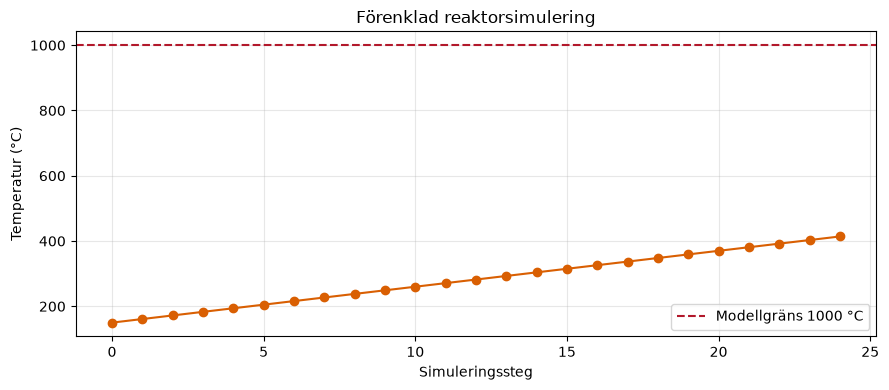

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(range(len(reactor_temperatures)), reactor_temperatures, marker='o', color='#d95f02')
plt.axhline(1000, color='#b2182b', linestyle='--', label='Modellgräns 1000 °C')
plt.title('Förenklad reaktorsimulering')
plt.xlabel('Simuleringssteg')
plt.ylabel('Temperatur (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Elpriskollen

API-format: `https://www.elprisetjustnu.se/api/v1/prices/ÅÅÅÅ/MM-DD_OMRÅDE.json`. Välj elområde nedan (`SE1`–`SE4`). Priserna i svaret visas i kr/kWh. Om API:t inte kan nås fortsätter notebooken med syntetiska exempelvärden, som aldrig presenteras som livepriser.

In [8]:
# Ändra till SE1, SE2 eller SE4 för ett annat svenskt elområde.
price_area = 'SE3'
if price_area not in {'SE1', 'SE2', 'SE3', 'SE4'}:
    raise ValueError('Elområdet måste vara SE1, SE2, SE3 eller SE4.')

price_date = date.today()
api_url = (
    f'https://www.elprisetjustnu.se/api/v1/prices/'
    f'{price_date:%Y}/{price_date:%m-%d}_{price_area}.json'
)

# Exempelvärden används bara om liveanropet misslyckas.
sample_prices = [
    0.42, 0.38, 0.35, 0.33, 0.36, 0.44, 0.61, 0.78,
    0.82, 0.76, 0.69, 0.63, 0.58, 0.61, 0.72, 0.91,
    1.08, 1.16, 1.02, 0.88, 0.74, 0.62, 0.54, 0.47,
]


def load_price_records(url, selected_date, fallback_prices, http_get=requests.get):
    """Hämta och normalisera API-data, eller returnera markerade demoresultat."""
    try:
        response = http_get(url, timeout=15)
        response.raise_for_status()
        payload = response.json()
        if not isinstance(payload, list) or not payload:
            raise ValueError('API-svaret innehöll ingen prislista.')

        records = []
        for item in payload:
            if 'time_start' not in item or 'SEK_per_kWh' not in item:
                raise ValueError('API-svaret saknar time_start eller SEK_per_kWh.')
            records.append({
                'time': datetime.fromisoformat(item['time_start'].replace('Z', '+00:00')),
                'price': float(item['SEK_per_kWh']),
            })
        records.sort(key=lambda item: item['time'])
        return records, 'Live-API'
    except (requests.RequestException, ValueError, KeyError, TypeError) as error:
        print(f'Kunde inte hämta livepriser: {error}')
        demo_records = [
            {
                'time': datetime.combine(selected_date, datetime.min.time()).replace(hour=hour),
                'price': price,
            }
            for hour, price in enumerate(fallback_prices)
        ]
        return demo_records, 'Exempeldata (offline/demo)'


price_records, data_source = load_price_records(api_url, price_date, sample_prices)
print(f'Elområde: {price_area} | Datum: {price_date:%Y-%m-%d}')
print(f'Datakälla: {data_source}')
print(f'Antal prisperioder: {len(price_records)}')
print(f'API-adress: {api_url}')

Elområde: SE3 | Datum: 2026-09-28
Datakälla: Live-API
Antal prisperioder: 96
API-adress: https://www.elprisetjustnu.se/api/v1/prices/2026/09-28_SE3.json


In [10]:
prices = [record['price'] for record in price_records]
if not prices:
    raise ValueError('Det finns inga prisvärden att analysera.')

lowest = min(price_records, key=lambda record: record['price'])
highest = max(price_records, key=lambda record: record['price'])
print(f'Lägsta pris: {lowest["price"]:.4f} kr/kWh kl. {lowest["time"]:%H:%M}')
print(f'Högsta pris: {highest["price"]:.4f} kr/kWh kl. {highest["time"]:%H:%M}')
print(f'Medelpris: {mean(prices):.4f} kr/kWh')
print(f'Medianpris: {median(prices):.4f} kr/kWh')
print('Obs: priserna är spotpriser från API:t; påslag, skatt och moms kan tillkomma.')

Lägsta pris: 0.0002 kr/kWh kl. 06:00
Högsta pris: 1.8400 kr/kWh kl. 18:00
Medelpris: 0.6552 kr/kWh
Medianpris: 0.5510 kr/kWh
Obs: priserna är spotpriser från API:t; påslag, skatt och moms kan tillkomma.


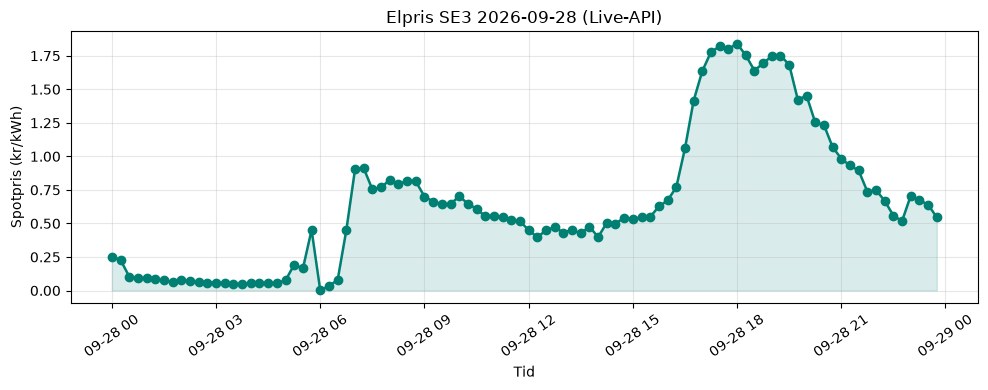

In [11]:
times = [record['time'] for record in price_records]
plt.figure(figsize=(10, 4))
plt.plot(times, prices, marker='o', linewidth=1.8, color='#007f73')
plt.fill_between(times, prices, alpha=0.15, color='#007f73')
plt.title(f'Elpris {price_area} {price_date:%Y-%m-%d} ({data_source})')
plt.xlabel('Tid')
plt.ylabel('Spotpris (kr/kWh)')
plt.xticks(rotation=35)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Källa och användning

Livepriser tillhandahålls av [Elpriset just nu](https://www.elprisetjustnu.se). Om resultaten publiceras, ange källan: *Elpriser tillhandahålls av Elpriset just nu.se*. Notebooken använder `requests` och `matplotlib`; installera dem med `python -m pip install requests matplotlib` om de saknas.

In [12]:
# Snabba kontroller av indata, simulering och prisdata.
assert len(reactor_temperatures) == 25
assert all(0 < temperature < 2000 for temperature in reactor_temperatures)
assert price_records
assert all(record['price'] >= 0 for record in price_records)
assert all('time' in record and 'price' in record for record in price_records)

try:
    validate_reactor_inputs(0, 5, 30, 6)
except ValueError:
    pass
else:
    raise AssertionError('Ogiltig starttemperatur godkändes.')


def simulate_offline_request(url, timeout):
    raise requests.Timeout('Simulerat nätverksfel för testet.')


offline_records, offline_source = load_price_records(
    api_url, price_date, sample_prices, http_get=simulate_offline_request
)
assert offline_source == 'Exempeldata (offline/demo)'
assert len(offline_records) == len(sample_prices)
assert offline_records[0]['price'] == sample_prices[0]
print('Alla kontroller godkända: indata, simulering, livepris och offline-fallback.')

Kunde inte hämta livepriser: Simulerat nätverksfel för testet.
Alla kontroller godkända: indata, simulering, livepris och offline-fallback.
